<div style="line-height:1.6; font-size:1.1em;">

<p style="text-align:center;"><i>Supplementary information for</i></p>

<h1 style="font-size:2.8em; text-align:center; margin-bottom:0.4em;">
Structure of Liquid Mercury at High Pressure
</h1>

<p style="font-size:1.3em; font-weight:600; text-align:center;">
James W. E. Drewitt<sup>a</sup>,
Benedict J. Heinen<sup>b</sup>,
Elena-Marie Rogmann<sup>b</sup>,
Oliver T. Lord<sup>b</sup>,
Francesco Turci<sup>a</sup>,
Adrian C. Barnes<sup>a</sup>,
Craig W. Wilson<sup>c</sup>,
Simon G. Macleod<sup>c</sup>,
and Annette K. Kleppe<sup>d</sup>
</p>

<br>
<p style="text-align:center;">
<sup>a</sup> School of Physics, University of Bristol, H.H. Wills Physics Laboratory,
Tyndall Avenue, Bristol, BS8 1TL, United Kingdom
<br>
<sup>b</sup> School of Earth Sciences, University of Bristol, Wills Memorial Building,
Queens Road, Bristol, BS8 1RJ, United Kingdom
<br>
<sup>c</sup> Atomic Weapons Establishment, Aldermaston, Reading RG7 4PR, United Kingdom
<br>
<sup>d</sup> Diamond Light Source Ltd, Diamond House, Harwell Science and Innovation Campus,
Chilton OX11 0DE, United Kingdom
</p>

<br>

<p style="text-align:center; font-size:1.05em;">
Published in <i>Physical Review B</i> (2026)<br>
DOI: <a href="https://doi.org/10.1103/nffz-z1g8">10.1103/nffz-z1g8</a>
</p>

<br>

<p style="text-align:center;">
Jupyter Notebook written by
<a href="mailto:oliver.lord@bristol.ac.uk">Oliver T. Lord</a>
(<a href="http://www.bristol.ac.uk/earthsciences/people/person/oliver-t-lord/overview.html">
School of Earth Sciences, University of Bristol</a>)
</p>

<br>

<p style="font-size:0.9em; text-align:justify;">
Copyright © 2026 Oliver Lord. This notebook is free software: you can redistribute it
and/or modify it under the terms of the GNU General Public License as published
by the Free Software Foundation, either version 3 of the License, or (at your option)
any later version.
This notebook is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.
A copy of the GNU General Public License can be found in the associated GitHub repository
and at <a href="https://www.gnu.org/licenses/">https://www.gnu.org/licenses/</a>.
</p>

</div>

<div style="line-height:1.6; font-size:1.1em;">

<h1 style="font-size:1.3em;font-weight:600;">Dependencies and global formatting</h1>

In [1]:
# Dependencies
# Suppress warnings
import warnings
import sys
import io
import logging

warnings.filterwarnings(
    "ignore",
    message="The '__version__' attribute is deprecated",
    category=UserWarning,
    module="session_info.main",
)
warnings.filterwarnings('ignore', category=FutureWarning, module='arviz')
warnings.filterwarnings('ignore', message='.*not compatible with tight_layout.*')
warnings.filterwarnings('ignore', message='.*Font family.*cursive.*not found.*')
# scipy.odr was deprecated in SciPy 1.17 (used by the ODR fits in this notebook);
# the API still works through 1.18, so silence the import-time DeprecationWarning.
warnings.filterwarnings('ignore', message=r'.*scipy\.odr.*deprecated.*', category=DeprecationWarning)
# matplotlib emits 'cursive font not found' messages via its font_manager logger
# (not warnings.warn), so warning filters don't catch them. The fallback is fine
# for our figures, so quiet the logger on systems without a cursive font (e.g. MyBinder).
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Import libraries
import numpy as np
import pandas as pd

# Suppress BurnMan's stdout warnings during import
old_stdout = sys.stdout
sys.stdout = io.StringIO()
import burnman as bm
sys.stdout = old_stdout

import uncertainties as u
import pandas as pd
import scipy.stats as stats
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numdifftools as nd
import bibtexparser
import session_info
import arviz as az
import matplotlib.colors as mcolors

# Import modules
from scipy.odr import RealData, Model, ODR
from scipy.stats import t
from scipy.optimize import minimize
from scipy.spatial import KDTree
from scipy.integrate import quad
from uncertainties import ufloat
from itables import init_notebook_mode, show
from matplotlib import rc
from IPython.display import Markdown

# Check for unused libraries and variables
#!jupyter nbconvert --to script Hg_melting.ipynb > /dev/null 2>&1
#!vulture Hg_melting.py

# Outputs all packages used in current session for creating requirements.txt file
session_info.show(write_req_file=True)

In [2]:
# Global formatting

# Initiate itables interactive mode; all pandas dataframes will be rendered using itables
init_notebook_mode(all_interactive=True)

# Global matplotlib formats with cross-platform font
plt.rcParams["mathtext.fontset"] = "custom"
# Use "serif" as fallback - will use Times New Roman on systems that have it
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.it"] = "serif:italic"
plt.rcParams["axes.linewidth"] = 1.2
plt.rc("xtick", labelsize=24)
plt.rc("ytick", labelsize=24)
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.use_mathtext'] = False  # optional

<div style="line-height:1.6; font-size:1.1em;">

<h1 style="font-size:1.3em;font-weight:600;">Classes and functions</h1>

In [3]:
class PhaseBoundaryModel:
    """
    Fit a 1D phase boundary y = f(x, params) using a misclassification-
    weighted orthogonal-distance loss.

    The loss penalizes only points that are on the "wrong" side of the
    model curve (based on `states` and the two state labels). Distances are
    computed orthogonally to a polyline discretization of the curve and
    weighted by the provided x/y uncertainties.

    Parameters
    ----------
    function : callable
        Model function mapping x -> y. Must accept signature
        `function(x, *params, implicit=False)` and return a scalar.
    initial_params : array_like
        Initial parameter guesses for optimization.
    x, y : array_like
        Data coordinates (1D arrays of equal length).
    x_sig, y_sig : array_like
        Standard deviations (uncertainties) for x and y. Broadcastable to
        the shapes of `x` and `y`.
    states : array_like
        Class labels for each (x, y) point. Used to determine which points
        are misclassified relative to the model curve.
    state_1, state_2 : hashable, optional
        Labels corresponding to the two phase fields (default: "liquid",
        "solid"). A point labeled `state_1` is considered misclassified if
        it lies below the curve; `state_2` is misclassified if above.
    curve_segments : int, optional
        Number of x-samples used to discretize the curve for nearest-point
        queries (default 1000).
    verbose : bool, optional
        If True, prints warnings during evaluation and fitting.

    Notes
    -----
    - The KD-tree search operates on a polyline obtained by sampling the
      model curve; increasing `curve_segments` improves accuracy at a cost
      to speed.
    - Degrees of freedom are computed as `len(x) - len(initial_params)`.
    """

    def __init__(
        self,
        function,
        initial_params,
        x,
        y,
        x_sig,
        y_sig,
        states,
        state_1="liquid",
        state_2="solid",
        curve_segments=1000,
        verbose=False,
    ):
        self.function = function
        self.initial_params = initial_params
        self.x = np.asarray(x)
        self.y = np.asarray(y)
        self.x_sig = np.asarray(x_sig)
        self.y_sig = np.asarray(y_sig)
        self.states = np.asarray(states)
        self.state_1 = state_1
        self.state_2 = state_2
        self.curve_segments = curve_segments
        self.verbose = verbose

    def _generate_curve_points(self, params):
        """
        Sample the model curve on an expanded x-range and return points.

        Parameters
        ----------
        params : array_like
            Model parameters.

        Returns
        -------
        ndarray, shape (curve_segments, 2)
            Columns are x and y coordinates of sampled curve points.

        Notes
        -----
        Tries a single vectorised model call first (the supported model
        functions accept array `x`); only falls back to a per-point loop if
        that raises. Non-finite outputs are replaced with mean(y), matching
        the original scalar-loop behaviour.
        """
        x_span = np.max(self.x) - np.min(self.x)
        x_min = np.min(self.x) - 0.1 * x_span
        x_max = np.max(self.x) + 0.1 * x_span
        x_points = np.linspace(x_min, x_max, self.curve_segments)

        y_mean = float(np.mean(self.y))
        try:
            y_arr = np.asarray(
                self.function(x_points, *params, implicit=False), dtype=float
            )
            bad = ~np.isfinite(y_arr)
            if bad.any():
                y_arr = np.where(bad, y_mean, y_arr)
            y_points = y_arr
        except Exception as e:
            if self.verbose:
                print(
                    f"Warning: vectorised evaluation failed ({e}); "
                    "falling back to per-point loop."
                )
            y_points = np.full_like(x_points, y_mean)
            for i, x_val in enumerate(x_points):
                try:
                    y_val = self.function(x_val, *params, implicit=False)
                    if np.isfinite(y_val):
                        y_points[i] = y_val
                except Exception:
                    pass

        return np.column_stack((x_points, y_points))

    def orthogonal_distance(self, params):
        """
        Compute the total misclassification-weighted orthogonal distance.

        Parameters
        ----------
        params : array_like
            Model parameters.

        Returns
        -------
        total_loss : float
            Sum of misclassification-weighted squared distances.
        pointwise_loss : ndarray or None
            Per-point contributions (same length as data), or None on error.
        """
        if np.any(np.isnan(params)) or np.any(np.isinf(params)):
            return 1e10, None

        try:
            curve_points = self._generate_curve_points(params)
            tree = KDTree(curve_points)

            data_points = np.column_stack((self.x, self.y))
            _, indices = tree.query(data_points)
            nearest_points = curve_points[indices]

            # Evaluate model curve at data x for classification test
            # Vectorised when the model supports array x; falls back to the
            # nearest-curve-point ordinate when the call raises or yields
            # non-finite values, matching the original scalar-loop behaviour.
            try:
                curve_y_arr = np.asarray(
                    self.function(self.x, *params, implicit=False), dtype=float
                )
                bad = ~np.isfinite(curve_y_arr)
                if bad.any():
                    curve_y_arr = np.where(bad, nearest_points[:, 1], curve_y_arr)
                curve_y = curve_y_arr
            except Exception:
                curve_y = nearest_points[:, 1].astype(float, copy=True)

            # Misclassification mask: penalize only points on the wrong side
            misclassified = np.zeros_like(self.x, dtype=int)
            misclassified[(self.states == self.state_1) & (self.y < curve_y)] = 1
            misclassified[(self.states == self.state_2) & (self.y > curve_y)] = 1

            # Weighted squared distances (orthogonal via nearest curve point)
            x_dist = ((self.x - nearest_points[:, 0]) ** 2) / np.where(
                self.x_sig > 0, self.x_sig ** 2, 1.0
            )
            y_dist = ((self.y - nearest_points[:, 1]) ** 2) / np.where(
                self.y_sig > 0, self.y_sig ** 2, 1.0
            )
            orthogonal_distances = x_dist + y_dist

            pointwise_loss = misclassified * orthogonal_distances
            total_loss = np.sum(pointwise_loss)

            if np.isnan(total_loss) or np.isinf(total_loss):
                return 1e10, pointwise_loss

            return total_loss, pointwise_loss

        except Exception as e:
            if self.verbose:
                print(f"Error in orthogonal_distance: {e}")
            return 1e10, None

    def calculate_dof(self):
        """
        Degrees of freedom: number of data points minus number of parameters.
        """
        return len(self.x) - len(self.initial_params)

    def calculate_confidence_intervals(
        self, optimal_params, confidence=0.95, return_cov=False
    ):
        """
        Compute parameter-wise confidence intervals via Hessian inversion.

        Parameters
        ----------
        optimal_params : array_like
            Parameter values at the (local) optimum.
        confidence : float, optional
            Two-sided confidence level (default 0.95).
        return_cov : bool, optional
            If True, also return the covariance matrix.

        Returns
        -------
        intervals : ndarray
            Half-widths of the confidence intervals for each parameter.
        covariance : ndarray, optional
            Parameter covariance matrix, only if `return_cov` is True.

        Notes
        -----
        - Uses `numdifftools.Hessian` to approximate the Hessian of the
          scalar loss, then inverts it for covariance.
        - If a variance on the diagonal is negative (due to numerical
          issues), falls back to a finite-difference second derivative
          for that parameter.
        """
        def scalar_loss(params):
            loss, _ = self.orthogonal_distance(params)
            return loss

        hess = nd.Hessian(scalar_loss)(optimal_params)

        try:
            covariance = np.linalg.inv(hess)
            diag_values = np.diag(covariance)
            std_errors = np.zeros_like(diag_values)

            for i, val in enumerate(diag_values):
                if val > 0:
                    std_errors[i] = np.sqrt(val)
                else:
                    # Fallback if negative variance estimate
                    if self.verbose:
                        print(
                            f"Warning: Negative variance for parameter {i}, "
                            "using finite-difference curvature."
                        )
                    eps = 1e-6 * max(abs(optimal_params[i]), 1.0)
                    params_plus = optimal_params.copy()
                    params_minus = optimal_params.copy()
                    params_plus[i] += eps
                    params_minus[i] -= eps
                    loss_plus, _ = self.orthogonal_distance(params_plus)
                    loss_minus, _ = self.orthogonal_distance(params_minus)
                    loss_orig, _ = self.orthogonal_distance(optimal_params)
                    second_deriv = (loss_plus - 2 * loss_orig + loss_minus) / (eps ** 2)
                    std_errors[i] = (
                        1.0 / np.sqrt(second_deriv) if second_deriv > 0 else float("inf")
                    )

            t_crit = stats.t.ppf((1 + confidence) / 2, self.calculate_dof())
            intervals = t_crit * std_errors

            if return_cov:
                return intervals, covariance
            return intervals

        except np.linalg.LinAlgError:
            if self.verbose:
                print("Warning: Hessian not invertible.")
            return np.array([float("inf")] * len(optimal_params))

    def fit(self):
        """
        Minimize the misclassification-weighted orthogonal-distance loss.

        Returns
        -------
        optimal_params : ndarray
            Best-fit parameters.
        loss : float
            Final scalar loss.
        dof : int
            Degrees of freedom.
        ci : ndarray
            Half-widths of parameter confidence intervals.
        point_losses : ndarray or None
            Per-point contributions at the optimum.
        cov : ndarray
            Parameter covariance matrix from Hessian inversion.

        Notes
        -----
        - Optimization uses Nelder–Mead with modest iteration/feval limits.
        - On any failure, returns the initial parameters and large fallback
          values so downstream code can handle the error gracefully.
        """
        def loss_only(params):
            total_loss, _ = self.orthogonal_distance(params)
            return total_loss

        try:
            result = minimize(
                loss_only,
                self.initial_params,
                method="Nelder-Mead",
                options={"maxiter": 1000, "maxfev": 2000},
            )

            optimal_params = result.x
            loss, point_losses = self.orthogonal_distance(optimal_params)
            dof = self.calculate_dof()
            ci, cov = self.calculate_confidence_intervals(
                optimal_params, return_cov=True
            )

            return optimal_params, loss, dof, ci, point_losses, cov

        except Exception as e:
            if self.verbose:
                print(f"Error during fitting: {e}")
            return (
                self.initial_params,
                1e10,
                self.calculate_dof(),
                np.array([float("inf")] * len(self.initial_params)),
                None,
            )

In [4]:
def calculate_d_spacing(wavelength, theta_deg):
    """
    Compute the lattice d-spacing from a 2θ value using Bragg's law.

    Parameters
    ----------
    wavelength : float
        X-ray wavelength in angstroms.
    theta_deg : float or array_like
        Diffraction angle (2θ) in degrees.

    Returns
    -------
    d_spacing : float or ndarray
        Interplanar spacing (Å) corresponding to the given angle(s).

    Notes
    -----
    Bragg's law: nλ = 2d sin θ  
    Here, θ = (2θ) / 2 and n = 1 (first-order reflection).
    """
    theta_rad = np.deg2rad(theta_deg)  # convert to radians
    d_spacing = wavelength / (2 * np.sin(theta_rad / 2))
    return d_spacing


# Create an uncertainty-wrapped version for ufloat compatibility
wrapped_calculate_d_spacing = u.wrap(calculate_d_spacing)

In [5]:
def cubic_lattice_volume(d_spacing, miller_indices, apuc=2, apfu=8, units="molar_pfu"):
    """
    Compute the cubic lattice volume per formula unit or per unit cell.

    Parameters
    ----------
    d_spacing : float
        Interplanar spacing (Å) for a reflection.
    miller_indices : tuple or list of int
        Miller indices (h, k, l) of the reflection.
    apuc : int, optional
        Number of atoms per unit cell (default 2 for NaCl-type structure).
    apfu : int, optional
        Number of atoms per formula unit (default 8 for NaCl-type).
    units : {'molar_pfu', 'unit_cell'}, optional
        Output unit. If 'molar_pfu', converts to molar volume per formula unit (m³/mol).

    Returns
    -------
    volume : float
        Lattice volume, either in Å³ (if `units != 'molar_pfu'`) or in m³/mol per formula unit.

    Notes
    -----
    - The cubic lattice constant `a` is related to `d` by  
      a = d * √(h² + k² + l²)
    - For molar conversion, uses Avogadro's number (6.022×10²³) and
      converts from Å³ to m³ (1 Å³ = 1e-30 m³).
    """
    h, k, l = miller_indices
    volume = (d_spacing * np.sqrt(h**2 + k**2 + l**2)) ** 3  # Å³ per unit cell

    if units == "molar_pfu":
        volume = (volume * 6.022e23) / (apfu / apuc) / 1e30  # m³/mol per formula unit

    return volume

In [6]:
def EMGD(T, V, params, T0=298.15, n_atoms=2):
    """
    Thermal pressure ΔP_th(V, T) (Pa) from the extended
    Mie–Grüneisen–Debye (EMGD) model of Dorogokupets & Dewaele (2007),
    relative to a reference temperature T0.

    Parameters
    ----------
    T : float or array_like
        Temperature(s) in K.
    V : float or array_like
        Molar volume(s) in m^3/mol (per formula unit).
    params : dict
        EMGD parameters with keys:
          - "V_0"        : reference molar volume (m^3/mol)
          - "theta0"     : Debye temperature at reference (K)
          - "gamma0"     : Grüneisen parameter at reference
          - "gamma_inf"  : Grüneisen parameter at infinite compression
          - "beta"       : exponent in γ(V) law
          - "a"          : intrinsic anharmonic coefficient (~1/K)
          - "m"          : anharmonic exponent in x^m, x = V/V_0
    T0 : float, optional
        Reference temperature in K, default 298.15 K.
    n_atoms : int, optional
        Number of atoms per formula unit (NaCl → 2).

    Returns
    -------
    dP_th : ndarray
        Thermal pressure (Pa) at (T, V) relative to T0.

    Notes
    -----
    - γ(V) = γ_inf + (γ0 − γ_inf) * (V/V0)^β
    - θ(V) = θ0 * (V/V0)^(-γ_inf) * exp[((γ0 − γ_inf)/β) * (1 − (V/V0)^β)]
    - Debye function (eq. 5): D(y) = (3/y^3) ∫_0^y z^3/(e^z − 1) dz
    - Quasi-harmonic energy (eq. 7): E_qh = 3 n R [ (3θ)/8 + T D(θ/T) ]
    - P_th = γ(V) [E_qh(T) − E_qh(T0)] / V  +  P_anh
    - P_anh from F_anh ∝ −T^2 yields:
        P_anh = (3/2) n R a m x^{m−1} (1/V0) [T^2 − T0^2],  x = V/V0

    """
    R = 8.314462618  # J/(mol·K)

    V = np.asarray(V, dtype=float)
    T = np.asarray(T, dtype=float)

    V0, th0, g0, ginf, be, a, mexp = [
        params[k] for k in ["V_0", "theta0", "gamma0", "gamma_inf", "beta", "a", "m"]
    ]
    x = V / V0

    # γ(V) and θ(V)
    gamma_V = ginf + (g0 - ginf) * x ** be
    theta_V = th0 * x ** (-ginf) * np.exp(((g0 - ginf) / be) * (1.0 - x ** be))

    def debye_D(theta_over_T):
        """
        Debye function D(θ/T) (eq. 5).
        Handles θ/T → 0 smoothly via series expansion.
        """
        y = float(theta_over_T)
        if y < 1e-8:
            # Series limit: D(y) ≈ 1 − y^2/20 + O(y^4)
            return 1.0 - (y * y) / 20.0

        def integrand(z):
            return (z ** 3) / np.expm1(z)

        val, _ = quad(integrand, 0.0, y, limit=200)
        return 3.0 * val / (y ** 3)

    def Eqh(theta, T_in, n_at):
        """
        Quasi-harmonic energy E_qh(V, T) (eq. 7), J/mol.

        Avoids ``np.vectorize`` (a Python loop with extra overhead) — the
        scalar branch covers the common case (T is a Python float) and the
        array branch loops directly via ``fromiter``.
        """
        theta = float(theta)
        T_arr = np.asarray(T_in, dtype=float)
        if T_arr.ndim == 0:
            D_vals = debye_D(theta / max(float(T_arr), 1e-12))
        else:
            D_vals = np.fromiter(
                (debye_D(theta / max(float(Ti), 1e-12)) for Ti in T_arr.ravel()),
                dtype=float, count=T_arr.size,
            ).reshape(T_arr.shape)
        return 3.0 * n_at * R * ((3.0 * theta) / 8.0 + T_arr * D_vals)

    # Quasi-harmonic contribution (no zero-point removal needed here—handled by Δ to T0)
    E_T = Eqh(theta_V, T, n_atoms)
    E_T0 = Eqh(theta_V, T0, n_atoms)
    dP_qh = (E_T - E_T0) * (gamma_V / V)

    # Intrinsic anharmonic term (eq. 10)
    dP_anh = (3.0 / 2.0) * n_atoms * R * a * mexp * x ** (mexp - 1.0) / V0 * (T ** 2 - T0 ** 2)

    return dP_qh + dP_anh

In [7]:
def params_to_vec_and_cov(params_dict, sigma_dict, order):
    """
    Convert parameter and uncertainty dictionaries into a parameter vector
    and diagonal covariance matrix following a specified key order.

    Parameters
    ----------
    params_dict : dict
        Dictionary of model parameters {name: value}.
    sigma_dict : dict
        Dictionary of corresponding 1σ standard deviations {name: sigma}.
    order : list of str
        Desired key order for the resulting vector and covariance matrix.

    Returns
    -------
    vec : ndarray, shape (n,)
        Ordered parameter vector.
    cov : ndarray, shape (n, n)
        Diagonal covariance matrix with variances σ² on the diagonal.

    Notes
    -----
    - This helper ensures consistent ordering of parameters when interfacing
      with fitting routines or uncertainty propagation (e.g., `cbands`).
    """
    vec = np.array([params_dict[k] for k in order], dtype=float)
    cov = np.diag(np.square([sigma_dict[k] for k in order]))
    return vec, cov

In [8]:
def fit_odr_model(x, y, model_func, beta0, xerr=None, yerr=None, fit_type=2):
    """
    Fit data using Orthogonal Distance Regression (ODR) or Ordinary
    Least Squares (OLS) via `scipy.odr`.

    Parameters
    ----------
    x : array_like
        Independent variable data.
    y : array_like
        Dependent variable data.
    model_func : callable
        Model function with signature `f(beta, x)` that returns predicted y.
    beta0 : array_like
        Initial guess for model parameters.
    xerr : array_like, optional
        Uncertainties (1σ) in `x`. Required for orthogonal fits.
    yerr : array_like, optional
        Uncertainties (1σ) in `y`.
    fit_type : int, optional
        Specifies the type of regression (default 2):
          - 0 → Orthogonal Distance Regression (ODR)
          - 2 → Ordinary Least Squares (vertical residuals, like `curve_fit`)

    Returns
    -------
    beta : ndarray
        Best-fit parameters.
    pcov : ndarray
        Parameter covariance matrix (scaled by residual variance).
    ci95 : ndarray
        95% confidence interval (±1.96σ equivalent for large N).

    Notes
    -----
    - Uses `scipy.odr.ODR` internally with `RealData` for uncertainty-aware fitting.
    - The returned covariance matrix `pcov` is computed as
      `cov_beta * res_var` to match `curve_fit` scaling.
    """
    model = Model(model_func)
    data = RealData(x, y, sx=xerr, sy=yerr)
    odr = ODR(data, model, beta0=beta0)
    odr.set_job(fit_type=fit_type)  # 0=ODR, 2=OLS
    out = odr.run()

    dof = len(x) - len(beta0)
    ci95 = t.ppf(0.975, dof) * out.sd_beta
    out.pcov = out.cov_beta * out.res_var  # scale to match curve_fit convention

    return out.beta, out.pcov, ci95

In [9]:
def cbands(
    func,
    beta,
    x,
    beta_cov,
    dof=None,
    x_sig=None,
    ifixb=None,
    confidence=0.95,
    x_1d_mode="auto",
    y_var=None,
    interval="confidence",
    # Optional training data (for automatic prediction variance)
    data_x=None,
    data_y=None,
    y_sig_data=None,
    kernel_bw=None,
    kernel_frac=0.08,
    # Anchor controls (for collapsing prediction bands at specific x in 1D)
    anchor_points=None,          # e.g. [0.0] to force zero band at ambient
    anchor_tol=1e-12,
    collapse_prediction_at_anchor=True,
    anchor_ramp_bw=None,         # absolute ramp half-width in x units
    anchor_ramp_frac=0.02,       # fraction of x-span if bw is None (≈2% default)
):
    """
    Delta-method confidence/prediction bands for y = func(x, beta).

    This computes the uncertainty in model output y given:
      • parameter covariance (beta_cov),
      • optional x-uncertainty (x_sig),
      • optional observation variance for prediction intervals (y_var).

    It supports scalar, vector (1D), and matrix (2D: rows = points, cols = vars)
    inputs for `x`. A 1D `x` can be interpreted as:
      - "points": n points of a single variable, or
      - "vars"  : a single point with n variables.
    Use `x_1d_mode` to choose, or leave "auto" to infer.

    For interval="prediction", you can either:
      • pass `y_var` explicitly (scalar or per-point),
      • or let the function infer a per-point observation variance by supplying
        (data_x, data_y, y_sig_data). The latter smooths y_sig_data**2 over x
        (Gaussian kernel) and adds a robust extra scatter term from residuals.

    Anchors (1D x only): If `anchor_points` is provided, prediction variance and
    x-uncertainty are smoothly ramped from 0 at the anchor(s) to full strength
    over `anchor_ramp_bw` (or `anchor_ramp_frac` × x-span if bw is None). This is
    useful, e.g., when the model is exactly known at a reference point.

    Parameters
    ----------
    func : callable
        Model function. Must accept either:
          (A) func(x, *beta)           OR
          (B) func(x, beta_array)
        and return a scalar for each x (per-row for 2D x).
    beta : array_like, shape (p,)
        Parameter vector at which to evaluate the bands.
    x : array_like
        Evaluation locations. Allowed shapes:
          - scalar
          - (n,)       (see `x_1d_mode`)
          - (n_points, n_vars)
    beta_cov : ndarray, shape (p, p)
        Parameter covariance matrix.
    dof : int or None, optional
        Degrees of freedom for critical value. If None or very large, uses
        normal z instead of Student t.
    x_sig : array_like, optional
        Standard deviations in x. Broadcastable to shape of x (per variable).
    ifixb : array_like of int, optional
        Flags for parameters: 1 = free (default), 0 = fixed.
        Length must match beta.
    confidence : float, optional
        Two-sided coverage probability (default 0.95).
    x_1d_mode : {"auto","points","vars"}, optional
        Interpretation for 1D x. See Notes above.
    y_var : float or array_like or None, optional
        Observation variance to add for prediction intervals. If None and
        interval="prediction", it will be inferred from training data.
    interval : {"confidence","prediction"}, optional
        Type of band:
          - "confidence": parameter (and optional x) uncertainty only.
          - "prediction": adds observation variance.
    data_x, data_y, y_sig_data : array_like, optional
        Training data used to infer observation variance when y_var is None.
        Only supported for 1D x.
    kernel_bw : float or None, optional
        Gaussian kernel bandwidth (x units) for smoothing y_sig_data**2 over x.
        If None, uses kernel_frac * (x-span).
    kernel_frac : float, optional
        Fraction of x-span to determine kernel_bw when not provided.
    anchor_points : float or sequence of float, optional
        Locations in 1D x where prediction/x-uncertainty collapse to zero.
    anchor_tol : float, optional
        Absolute tolerance to identify exact anchors.
    collapse_prediction_at_anchor : bool, optional
        If True, taper prediction variance and x_sig to zero at anchors.
    anchor_ramp_bw : float or None, optional
        Absolute ramp width from 0 (at anchor) to full variance. If None, uses
        anchor_ramp_frac × (x-span).
    anchor_ramp_frac : float, optional
        Fraction of x-span used as ramp width when anchor_ramp_bw is None.

    Returns
    -------
    half_width : ndarray, shape (n_points,)
        Half-widths of the requested bands at each evaluation x (± half_width).

    Notes
    -----
    - The delta method uses first-order finite differences to approximate
      sensitivities of y with respect to beta and x.
    - For 1D x in "auto" mode, the function chooses "vars" if x_sig looks like
      per-variable sigmas or if dof <= 1, otherwise "points".
    - For anchors, the same ramp is applied to x_sig and the observation variance.

    """
    # ---------- utilities ----------
    def robust_var(a):
        mad = np.median(np.abs(a - np.median(a)))
        return (1.4826 * mad) ** 2

    def kernel_smooth_var(x_train, v_train, x_eval, bw):
        D = (x_eval[:, None] - x_train[None, :]) / (bw + 1e-12)
        W = np.exp(-0.5 * D ** 2)
        num = (W * v_train[None, :]).sum(axis=1)
        den = W.sum(axis=1) + 1e-12
        return num / den

    def smoothstep(z):
        # 0 → 1 with zero slope at both ends
        z = np.clip(z, 0.0, 1.0)
        return z * z * (3.0 - 2.0 * z)

    # ---------- inputs & shapes ----------
    beta = np.atleast_1d(np.asarray(beta, dtype=float))
    p = beta.size
    beta_cov = np.atleast_2d(np.asarray(beta_cov, dtype=float))
    if beta_cov.shape != (p, p):
        raise ValueError("beta_cov must be a square (p x p) covariance matrix.")

    if ifixb is None:
        ifixb = np.ones(p, dtype=int)
    else:
        ifixb = np.asarray(ifixb, dtype=int)
        if ifixb.size != p:
            raise ValueError("ifixb must have same length as beta.")

    X_raw = np.asarray(x)

    # 1D interpretation helper
    def _interpret_1d_as_vars(x1d):
        if x_sig is not None:
            xs = np.asarray(x_sig)
            if xs.ndim <= 1 and xs.size == x1d.size:
                return True
        if dof <= 1:
            return True
        return False

    # Normalize X -> (n_points, n_vars)
    if X_raw.ndim == 0:
        X = X_raw.reshape(1, 1)
    elif X_raw.ndim == 1:
        as_vars = (
            _interpret_1d_as_vars(X_raw) if x_1d_mode == "auto" else (x_1d_mode == "vars")
        )
        X = X_raw.reshape(1, -1) if as_vars else X_raw.reshape(-1, 1)
    elif X_raw.ndim == 2:
        X = X_raw
    else:
        raise ValueError("x must be scalar, 1-D, or 2-D.")
    n_points, n_vars = X.shape

    # Normalize x_sig -> (n_points, n_vars)
    if x_sig is None:
        Xsig = np.zeros((n_points, n_vars), dtype=float)
    else:
        xs = np.asarray(x_sig, dtype=float)
        if xs.ndim == 0:
            Xsig = np.full((n_points, n_vars), float(xs))
        elif xs.ndim == 1:
            if n_vars == 1 and xs.size == n_points:
                Xsig = xs.reshape(n_points, 1)
            elif xs.size == n_vars:
                Xsig = np.tile(xs.reshape(1, n_vars), (n_points, 1))
            elif X_raw.ndim == 1 and xs.size == X_raw.size:
                Xsig = np.tile(xs.reshape(1, -1), (n_points, 1))
            else:
                raise ValueError("x_sig shape ambiguous.")
        elif xs.ndim == 2:
            if xs.shape != (n_points, n_vars):
                raise ValueError("x_sig must match x shape (n_points, n_vars).")
            Xsig = xs
        else:
            raise ValueError("x_sig must be scalar, 1-D, or 2-D.")

    # ---------- anchor ramp weights (1D x only) ----------
    ramp_w = np.ones(n_points, dtype=float)  # default: no ramp
    anchor_mask = np.zeros(n_points, dtype=bool)
    if anchor_points is not None and n_vars == 1:
        ap = np.atleast_1d(anchor_points).astype(float)
        xvec = X[:, 0].astype(float)

        # Minimum distance to any anchor
        dmin = (
            np.min([np.abs(xvec - a) for a in ap], axis=0) if ap.size > 0 else np.abs(xvec)
        )

        # Ramp width
        if anchor_ramp_bw is None:
            span = float(np.max(xvec) - np.min(xvec)) if xvec.size else 0.0
            anchor_ramp_bw = max(anchor_ramp_frac * span, 1e-15)

        # Smooth step from 0 at anchor to 1 by distance = anchor_ramp_bw
        ramp_w = smoothstep(dmin / max(anchor_ramp_bw, 1e-15))

        # Exact anchors -> enforce 0
        for a in ap:
            anchor_mask |= np.isclose(xvec, float(a), atol=anchor_tol)
        ramp_w[anchor_mask] = 0.0

    # Local copy of x_sig, tapered near anchors
    Xsig_local = Xsig.copy()
    if collapse_prediction_at_anchor and n_vars == 1 and anchor_points is not None:
        Xsig_local = (Xsig_local.T * ramp_w).T

    # ---------- model evaluation helpers ----------
    def _call_model(xi, params):
        try:
            return func(xi, *params)
        except TypeError:
            return func(xi, params)

    def _model_at_row(row_vec, params):
        xi = row_vec[0] if n_vars == 1 else row_vec
        y = _call_model(xi, params)
        y_arr = np.asarray(y)
        if y_arr.size != 1:
            raise ValueError("Model must return scalar per row.")
        return float(y_arr.squeeze())

    # Nominal model values at evaluation points
    y_values = np.array([_model_at_row(X[i], beta) for i in range(n_points)])

    # Finite-difference step
    def _step(val, rel=1e-6, absmin=1e-8):
        v = float(val)
        h = rel * abs(v)
        return h if h != 0.0 else absmin

    # ---------- delta-method variance from params & x ----------
    var_y = np.empty(n_points, dtype=float)
    for i in range(n_points):
        g = np.zeros(p + n_vars, dtype=float)

        # dy/dbeta
        for j in range(p):
            if ifixb[j] != 1:
                continue
            params_pert = beta.copy()
            h = _step(beta[j])
            params_pert[j] = beta[j] + h
            y_plus = _model_at_row(X[i], params_pert)
            y0 = y_values[i]
            g[j] = (y_plus - y0) / h

        # dy/dx
        for k in range(n_vars):
            h = _step(X[i, k])
            Xi = X[i].copy()
            Xi[k] = X[i, k] + h
            y_plus = _model_at_row(Xi, beta)
            y0 = y_values[i]
            g[p + k] = (y_plus - y0) / h

        # Var(y) = g^T Cov_full g, where Cov_full blocks are Cov(beta) and Cov(x)
        cov_x = np.diag(np.square(Xsig_local[i]))
        cov_full = np.block(
            [
                [beta_cov, np.zeros((p, n_vars))],
                [np.zeros((n_vars, p)), cov_x],
            ]
        )
        var_y[i] = g @ cov_full @ g

    # ---------- add observation variance for prediction ----------
    if interval.lower() == "prediction":
        if y_var is None:
            # Infer observation variance from training data (1D x only)
            if data_x is None or data_y is None or y_sig_data is None:
                raise ValueError("Provide (data_x, data_y, y_sig_data) or pass y_var.")
            if n_vars != 1:
                raise ValueError("Automatic prediction variance supports 1D x only.")

            data_x = np.asarray(data_x, dtype=float)
            data_y = np.asarray(data_y, dtype=float)
            y_sig_data = np.asarray(y_sig_data, dtype=float)

            # Residual-based extra scatter
            y_hat_train = np.array([_call_model(xi, beta) for xi in data_x])
            resid = data_y - y_hat_train
            s2_resid = robust_var(resid)
            typ_meas_var = np.nanmedian(y_sig_data ** 2)
            s2_extra = max(0.0, s2_resid - typ_meas_var)

            # Smooth measurement variance to evaluation x
            if kernel_bw is None:
                span = float(np.max(data_x) - np.min(data_x)) if data_x.size else 0.0
                kernel_bw = kernel_frac * span if span > 0 else 1.0

            y_var_meas_pred = kernel_smooth_var(
                data_x, y_sig_data ** 2, X[:, 0], kernel_bw
            )
            y_var_meas_pred = np.maximum(y_var_meas_pred, 0.0)

            obs_var = y_var_meas_pred + s2_extra
        else:
            # Use provided observation variance (scalar or per-point)
            y_var_arr = np.asarray(y_var, dtype=float)
            if y_var_arr.ndim == 0:
                obs_var = np.full(n_points, float(y_var_arr))
            else:
                obs_var = y_var_arr.copy()
                if obs_var.shape[0] != n_points:
                    raise ValueError(
                        "y_var array length must match number of x points."
                    )

        # Taper observation variance near anchors (1D only)
        if collapse_prediction_at_anchor and n_vars == 1 and anchor_points is not None:
            obs_var = obs_var * ramp_w

        var_y = var_y + obs_var

    # ---------- critical value & half-width ----------
    alpha_mid = 0.5 * (1.0 + confidence)
    if dof is None or np.isinf(dof) or dof >= 1e6:
        Ccrit = stats.norm.ppf(alpha_mid)  # z
    else:
        Ccrit = stats.t.ppf(alpha_mid, dof)  # t

    return np.sqrt(np.maximum(var_y, 0.0)) * Ccrit

In [10]:
def ivw_mean(vals, errs):
    """
    Compute the inverse-variance–weighted (IVW) mean and its standard error.

    Parameters
    ----------
    vals : array_like
        Array of observed values.
    errs : array_like
        Corresponding 1σ uncertainties for each value.

    Returns
    -------
    mu : float
        Inverse-variance–weighted mean.
    se : float
        Standard error of the weighted mean.

    Notes
    -----
    - Weights are defined as w = 1 / σ².
    - A small floor (1e-300) prevents division by zero.
    """
    w = 1.0 / np.maximum(errs, 1e-300) ** 2  # weights = 1 / σ²
    mu = np.sum(w * vals) / np.sum(w)        # weighted mean
    se = np.sqrt(1.0 / np.sum(w))            # standard error
    return mu, se

In [11]:
def Simon_Glatzel(x, a, c, implicit=False):
    """
    Simon–Glatzel equation for a melting (or phase boundary) curve.

    Parameters
    ----------
    x : float or array_like
        Pressure (GPa) when `implicit=False`, or an array-like [P, T]
        when `implicit=True`.
    a : float
        Simon–Glatzel constant (pressure scaling term).
    c : float
        Simon–Glatzel exponent.
    implicit : bool, optional
        If True, returns an implicit form f(P, T) = 0 suitable for solvers.
        If False (default), returns temperature as an explicit function of pressure.

    Returns
    -------
    float or ndarray
        Temperature (K) corresponding to the given pressure(s), or residuals
        for implicit form.

    Notes
    -----
    The equation is expressed as:

        T = T₀ * [(P / a) + 1]^(1 / c)

    where T₀ = 234.32 K is the reference temperature at 0 GPa.
    """
    T0 = 234.32  # reference temperature in K

    if implicit:
        # f(P, T) = T - T_model(P)
        P, T = x
        return T - (((P / a) + 1) ** (1 / c)) * T0
    else:
        P = np.asarray(x, dtype=float)
        return (((P / a) + 1) ** (1 / c)) * T0


def Simon_Glatzel_ODR(beta, x):
    """
    Wrapper for Orthogonal Distance Regression (ODR).

    Parameters
    ----------
    beta : sequence
        Parameter vector [a, c].
    x : array_like
        Pressure (GPa).

    Returns
    -------
    float or ndarray
        Model temperature (K) evaluated at each input pressure.
    """
    a, c = beta
    return Simon_Glatzel(x, a, c)

In [12]:
def Kechin(P, a, b, c, implicit=False):
    """
    Kechin melting (or phase boundary) equation.

    From: Kechin, V. V. (2002), *Phys. Rev. B*, 65, 052102.  
    DOI: https://doi.org/10.1103/PhysRevB.65.052102

    Parameters
    ----------
    P : float or array_like
        Pressure (GPa) when `implicit=False`, or [P, T] when `implicit=True`.
    a : float
        Pressure scaling constant.
    b : float
        Exponential power-law exponent.
    c : float
        Damping (exponential decay) coefficient.
    implicit : bool, optional
        If True, returns the implicit form f(P, T) = 0,  
        suitable for use in solvers (default False).

    Returns
    -------
    float or ndarray
        Temperature (K) corresponding to the given pressure(s),
        or residuals for implicit form.

    Notes
    -----
    Explicit form:
        T(P) = T₀ * (1 + P / a)^b * exp(-c * P)

    where T₀ = 234.32 K is the melting temperature at 0 GPa.
    """
    T0 = 234.32  # reference melting point at 0 GPa (K)

    if implicit:
        # f(P, T) = T - T_model(P)
        P_val, T_val = P
        return T_val - T0 * (1 + P_val / a) ** b * np.exp(-c * P_val)
    else:
        P = np.asarray(P, dtype=float)
        return T0 * (1 + P / a) ** b * np.exp(-c * P)

In [13]:
def poly3(P, a, b, c):
    """
    Third-order polynomial function for phase boundary fitting.

    Parameters
    ----------
    P : float or array_like
        Pressure (GPa) or independent variable.
    a, b, c : float
        Polynomial coefficients where:
            T(P) = a * P² + b * P + c

    Returns
    -------
    float or ndarray
        Computed temperature (K) or dependent variable.
    """
    return a * P**2 + b * P + c


def poly3_ODR(beta, x):
    """
    Wrapper for Orthogonal Distance Regression (ODR).

    Parameters
    ----------
    beta : sequence
        Parameter vector [a, b, c].
    x : array_like
        Pressure (GPa) or independent variable.

    Returns
    -------
    float or ndarray
        Model temperature (K) evaluated at each input pressure.
    """
    a, b, c = beta
    return poly3(x, a, b, c)

In [14]:
def load_bib_as_dict(bib_file_path):
    """
    Parse a .bib file and return a dictionary mapping citekeys to formatted
    reference strings. Handles common BibTeX fields gracefully.

    Author formatting:
        - One author: full name
        - Two authors: "A & B"
        - Three or more authors: "A et al."

    Parameters
    ----------
    bib_file_path : str
        Path to the .bib file.

    Returns
    -------
    dict
        Dictionary of the form:
        {
            "citekey": "Author(s) (Year). Title. Journal, Volume, Pages, URL"
        }
    """
    with open(bib_file_path, encoding="utf-8") as bibtex_file:
        bib_database = bibtexparser.load(bibtex_file)

    reference_dict = {}
    for entry in bib_database.entries:
        key = entry.get("ID", "unknown")

        # --- Author formatting ---
        raw_authors = entry.get("author", "Unknown Author").replace("\n", " ")
        authors_list = [a.strip() for a in raw_authors.split(" and ") if a.strip()]

        if len(authors_list) == 1:
            authors = authors_list[0]
        elif len(authors_list) == 2:
            authors = f"{authors_list[0]} & {authors_list[1]}"
        else:
            authors = f"{authors_list[0]} et al."

        # --- Extract core fields ---
        title = entry.get("title", "Untitled")
        year = entry.get("year", "n.d.")
        journal = entry.get("journal", entry.get("booktitle", ""))
        volume = entry.get("volume", "")
        pages = entry.get("pages", "")
        url = entry.get("url", "")

        # --- Build formatted reference ---
        reference = f"{authors} ({year}). {title}. {journal}"
        if volume:
            reference += f", {volume}"
        if pages:
            reference += f", {pages}"
        if url:
            reference += f", {url}"

        reference_dict[key] = reference

    return reference_dict

In [15]:
def consistent_figsize(nrows, ncols, panel_w, panel_h, wspace=0.2, hspace=0.2):
    """
    Compute a consistent matplotlib `figsize` for subplot grids.

    Ensures that each panel in a figure grid has the same physical size
    (in inches), while accounting for inter-panel spacing.

    Parameters
    ----------
    nrows : int
        Number of subplot rows.
    ncols : int
        Number of subplot columns.
    panel_w : float
        Width of a single panel, in inches.
    panel_h : float
        Height of a single panel, in inches.
    wspace : float, optional
        Fractional horizontal spacing between panels (default = 0.2).
    hspace : float, optional
        Fractional vertical spacing between panels (default = 0.2).

    Returns
    -------
    tuple of float
        (width, height) in inches — suitable for use as `figsize` in `plt.figure`.

    Examples
    --------
    >>> figsize = consistent_figsize(2, 3, panel_w=3, panel_h=2.5)
    >>> fig, axes = plt.subplots(2, 3, figsize=figsize)
    """
    # Compute total figure dimensions in inches
    width = ncols * panel_w + (ncols - 1) * panel_w * wspace
    height = nrows * panel_h + (nrows - 1) * panel_h * hspace

    return width, height

In [16]:
def _format_vals_errs(vals, errs, sig_fig_err=2):
    """
    Return two parallel lists of strings (value, error) where:
    - error is shown with `sig_fig_err` significant figures
    - value is rounded to the same decimal place as its error
    """
    out_vals, out_errs = [], []
    for v, e in zip(vals, errs):
        # Handle non-positive or non-finite uncertainties gracefully
        if not np.isfinite(e) or e <= 0:
            out_vals.append(f"{v:.6g}")
            out_errs.append("")
            continue

        # Determine decimals so that 'e' has `sig_fig_err` significant figures
        exp = int(np.floor(np.log10(abs(e))))
        # decimal places to print = sig figs minus 1 minus exponent
        dec = max(0, sig_fig_err - 1 - exp)

        out_vals.append(f"{v:.{dec}f}")
        out_errs.append(f"{e:.{dec}f}")
    return out_vals, out_errs

In [17]:
def _trunc_3dp(x: float) -> float:
    """Truncate (not round) a scalar to 3 decimal places."""
    return np.trunc(x * 1000.0) / 1000.0

In [18]:
def plot_points(ax, df, marker, ms, face, edge="black", z=3):
    """Plot styled errorbar points."""
    ax.errorbar(
        df["P_tot (GPa)"], df["T (K)"],
        xerr=df["P_tot_error (GPa)"], yerr=df["T error"],
        fmt=marker, markersize=ms, color=edge, markeredgecolor=edge,
        ecolor="black", markerfacecolor=face, alpha=1.0, capsize=0,
        elinewidth=2, zorder=z
    )

In [19]:
def residuals_vs(model_func, beta, df):
    """Residuals: data T minus model T at given P."""
    return df["T (K)"] - model_func(df["P_tot (GPa)"], *beta)

<br>
<h1 style="font-size:2.4em;">The Hg Phase Diagram</h1>

<div style="line-height:1.6;">

<h2 style='text-align: left;'>Previous studies</h2>

<h3 style='text-align: left;'>Table S1: data from previous studies</h3>

<p>
Data points representing the melting curve and the 
<span style="font-style:italic;">α/β</span> reaction boundary were extracted from 
Fig. 1 of Klement et al. (1963)<sup><a href="#ref1">1</a></sup> and references 
therein<sup><a href="#ref2">2</a>–<a href="#ref6">6</a></sup> using 
<a href="https://plotdigitizer.com/">PlotDigitizer</a>. 
</p>

</div>

In [20]:
# Load data from previous studies

df = pd.read_csv("./literature_data.csv")
df_display = df.copy()
df_display["P (GPa)"] = df_display["P (GPa)"].map(lambda x: f"{x:.2f}")
df_display["T (K)"] = df_display["T (K)"].map(lambda x: f"{x:.0f}")

show(
    df_display,
    scrollY="500px",
    scrollX=True,
    scrollCollapse=True,
    paging=False,
    style="table-layout:auto;width:100%;float:left",
)

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


### Table S2: fits to literature data

Best-fit parameters and their corresponding standard errors for fits to the published melting and solid–solid transition data for mercury (Hg) from table 1.  

The α–liquid boundary is modelled using the Simon–Glatzel relation<sup><a href="#ref7">7</a></sup>:

<br>
<a id="eq1"></a>
$$
T = T_0 \left(1 + \frac{P}{a}\right)^{1/c} \tag{1}
$$
</div>
<br>


where $T_0$ is the reference melting temperature at ambient pressure (here fixed at 234.32 K), and $a$ and $c$ are fitted parameters.  

The β–α boundary is fitted to a third-degree polynomial which captures the non-linearity of the transition well:

<br>
<a id="eq2"></a>
<div style="text-align:left">
$$
T = c_0 P^2 + c_1 P + c_2 \tag{2}
$$
</div>
<br>

Both datasets were fitted using orthogonal distance regression (ODR) as implemented in the Scipy library<sup><a href="#ref8">8</a></sup>:, which accounts for uncertainties in both the pressure and temperature variables. According to Klement et al (1963)<sup><a href="#ref1">1</a></sup>, pressure uncertainties in the piston-cylinder apparatus used for their experiments range from 0.05 GPa up to 4.5 GPa and up to 0.2 GPa at 7 GPa. We have therefore applied uncertainties to each data point that vary smoothly as a function of pressure from 0 at ambient pressure and through these two higher pressure anchor points. Temperature uncertainties are reported as ±1-2 K and so we apply 2 K of uncertainty to all data points. It should be noted that in both cases, these uncertainties are estimates based on calibrations (in the case of pressure) and assumed uncertainties in thermocouples, without taking into account the effects of pressure on thermocouple e.m.f., and certaintly do not consider the possibility of underestimates of temperature due to the offset of the thermocouple junction with the sample, which may also vary as a function of pressure. 

In [21]:
from scipy.interpolate import PchipInterpolator

# --- Smooth pressure-uncertainty model σ_P(P) through (0,0), (4.5,0.05), (7,0.20) GPa ---
_P_nodes = np.array([0.0, 4.5, 7.0], dtype=float)
_S_nodes = np.array([0.0, 0.05, 0.20], dtype=float)  # GPa
_pchip_sigmaP = PchipInterpolator(_P_nodes, _S_nodes, extrapolate=True)

def pressure_sigma(P):
    """Smooth, monotone σ_P(P) in GPa; clamps below 0 GPa and extrapolates above 7 GPa."""
    P = np.asarray(P, dtype=float)
    # No negative pressures; extrapolate for P > 7 with PCHIP's last slope
    P_clamped = np.maximum(P, 0.0)
    return np.maximum(_pchip_sigmaP(P_clamped), 0.0)

# ============================================================
# Fit literature data (Simon–Glatzel for α–liquid; poly3 for β–α)
# ============================================================

# --- Select subsets ---
P_al = df.loc[df["boundary"] == "alpha/liquid", "P (GPa)"].values
T_al = df.loc[df["boundary"] == "alpha/liquid", "T (K)"].values

P_ba = df.loc[df["boundary"] == "beta/alpha", "P (GPa)"].values
T_ba = df.loc[df["boundary"] == "beta/alpha", "T (K)"].values

# --- Build per-point uncertainties ---
xerr_al = pressure_sigma(P_al)       
xerr_ba = pressure_sigma(P_ba)        
yerr_al = np.full_like(T_al, 2.0, dtype=float) 
yerr_ba = np.full_like(T_ba, 2.0, dtype=float) 

# --- ODR fits (orthogonal) ---
beta_al, cov_al, sigma_al = fit_odr_model(
    P_al, T_al,
    model_func=Simon_Glatzel_ODR,
    beta0=[2.38, 1.71],
    xerr=xerr_al,
    yerr=yerr_al,
    fit_type=0,
)

beta_ba, cov_ba, sigma_ba = fit_odr_model(
    P_ba, T_ba,
    model_func=poly3_ODR,
    beta0=[1.0, 2.0, 3.0],
    xerr=xerr_ba,
    yerr=yerr_ba,
    fit_type=0,
)

# --- Display table (unchanged) ---
param_names = [
    "α–Liquid Boundary, Simon–Glatzel Fit", "a", "c",
    "β–α Boundary, 3rd degree polynomial fit", "c0", "c1", "c2",
]

al_vals_str, al_errs_str = _format_vals_errs(beta_al, sigma_al, sig_fig_err=2)
ba_vals_str, ba_errs_str = _format_vals_errs(beta_ba, sigma_ba, sig_fig_err=2)

estimates = ["", *al_vals_str, "", *ba_vals_str]
errors    = ["", *al_errs_str, "", *ba_errs_str]

df_al = pd.DataFrame(
    {"Parameter": param_names, "Estimate": estimates, "Std. Error": errors}
)

show(df_al, scrollX=False, style="margin-center: 0; text-align: center; ")

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


## This study

### Table S3: Pressure calibration test

Residuals after subtracting the reference isochores for NaCl-B1 published in table 10 of Dorogokupets & Dewaele (2007)<sup><a href="#ref9">9</a></sup> from values calculated at the same temperatures and compression ratios using the EMGD function (Extended Mie-Grueneisen-Debye and the fitted parameters from table 1 of the same reference. The base isotherm uses the Vinet formalism as implemented in the *BurnMan* library<sup><a href="#ref10">10</a></sup>.

The total pressure at a given volume $V$ and temperature $T$ is expressed as:
<br>
<a id="eq3"></a>
<div style="text-align:left">
$$
P(V,T) = P_{300}(V) + P_{\mathrm{th}}(V,T) \tag{3}
$$
</div>
<br>

where $P_{300}$ is the pressure at 300 K, and $P_{\mathrm{th}}$ is the thermal pressure. The Vinet equation of state is used to compute $P_{300}(V)$:

<br>
<a id="eq4"></a>
<div style="text-align:left">
$$
P_{300}(V) = 3K_0 \left(\frac{V}{V_0}\right)^{-\tfrac{2}{3}}
              \left[1 - \left(\frac{V}{V_0}\right)^{\tfrac{1}{3}}\right]
              \exp\!\left\{\tfrac{3}{2}(K_0' - 1)
              \left[1 - \left(\frac{V}{V_0}\right)^{\tfrac{1}{3}}\right]\right\}
              + P_0 \tag{4}
$$
</div>
<br>

where $K_0$ is the bulk modulus, $K_0'$ its pressure derivative, and $V_0$ the molar volume at ambient conditions. The thermal pressure term is given by:

<br>
<a id="eq5"></a>
<div style="text-align:left">
$$
P_{\mathrm{th}}(V,T) = P_{\mathrm{qh}}(V,T) + P_{\mathrm{anh}}(V,T) \tag{5}
$$
</div>
<br>

$P_{\mathrm{qh}}(V,T)$ is the quasi-harmonic part, which follows from the vibrational internal energy $E_{\mathrm{qh}}$:

<br>
<a id="eq6"></a>
<div style="text-align:left">
$$
P_{\mathrm{qh}}(V,T) = \frac{\gamma(V)}{V}
\left[ E_{\mathrm{qh}}(V,T) - E_{\mathrm{qh}}(V,T_0) \right] \tag{6}
$$
</div>
<br>

where the Grüneisen parameter and Debye temperature vary with compression as:

<br>
<a id="eq7"></a>
<div style="text-align:left">
$$
\gamma(V) = \gamma_\infty + (\gamma_0 - \gamma_\infty)
\left(\frac{V}{V_0}\right)^{\beta} \tag{7}
$$
</div>
<br>

<br>
<a id="eq8"></a>
<div style="text-align:left">
$$
\Theta(V) = \Theta_0
\left(\frac{V}{V_0}\right)^{-\gamma_\infty}
\exp\!\left[\frac{\gamma_0 - \gamma_\infty}{\beta}
\left(1 - \left(\frac{V}{V_0}\right)^{\beta}\right)\right] \tag{8}
$$
</div>
<br>

The quasi-harmonic internal energy per mole is then:

<br>
<a id="eq9"></a>
<div style="text-align:left">
$$
E_{\mathrm{qh}}(V,T) =
3nR \left[\frac{3}{8}\Theta(V) + T D\!\left(\frac{\Theta(V)}{T}\right)\right] \tag{9}
$$
</div>
<br>

where $D(\Theta(V)/T)$ is the Debye integral:

<br>
<a id="eq10"></a>
<div style="text-align:left">
$$
D(y) = \frac{3}{y^3}\int_0^y \frac{z^3}{e^z - 1} \, dz \tag{10}
$$
</div>
<br>

The dimensionless integration variable $z$ is defined as

<br>
<a id="eq10"></a>
<div style="text-align:left">
$$
z = \frac{\hbar \omega}{k_{\mathrm{B}} T} \tag{11}
$$
</div>
<br>

where $\hbar$ is the reduced Planck constant, $\omega$ is the phonon angular frequency, $k_{\mathrm{B}}$ is the Boltzmann constant, and $T$ is the absolute temperature. The integral therefore represents a summation over all phonon modes up to the Debye frequency (corresponding to $z = \Theta/T$), weighted by their Bose–Einstein occupation factor $(e^z - 1)^{-1}$.

An intrinsic anharmonic correction is included as:

<br>
<a id="eq11"></a>
<div style="text-align:left">
$$
P_{\mathrm{anh}}(V,T)
 = \frac{3}{2}nR a m
 \frac{1}{V_0}\left(\frac{V}{V_0}\right)^{m-1}
 \left(T^2 - T_0^2\right) \tag{12}
$$
</div>
<br>

where $a$ and $m$ are empirical parameters describing the anharmonic term, $R$ is the gas constant, and $n$ is the number of atoms per formula unit.

Residuals between calculated and reference pressures are in the MPa range, with a maximum of 10 MPa at ambient volume and 2000 K, likely reflecting the limited precision (truncated significant figures) of the parameters published in Dorogokupets & Dewaele (2007)<sup><a href="#ref9">9</a></sup>.

In [22]:
# Pressure calibration: NaCl–B1 (Dorogokupets & Dewaele, 2007)
#   DOI: https://doi.org/10.1080/08957950701659700
# - Vinet for the 300 K isotherm (P_300)
# - EMGD for thermal term (P_th)
# - Compare against Table 10 isochores; show residuals (calc − ref)
# - Display values truncated (not rounded) to 3 d.p.
# ============================================================

# ---- Inputs: model parameters (Table 1) ----
beta_nacl_b1 = {
    "V_0": 27.015e-6,        # m^3/mol
    "K_0": 23.83e9,          # Pa
    "Kprime_0": 5.0920319,   # -
    "theta0": 270.0,         # K
    "gamma0": 1.64,          # -
    "gamma_inf": 1.12,       # -
    "beta": 4.36,            # -
    "a": -24.0e-6,           # 1/K (sign per paper)
    "m": 7.02,               # -
    "T_0": 298.15,           # K
    "P_0": 1e5               # Pa
}

# ---- Assumed parameter uncertainties (for later CI work) ----
sigma_nacl_b1 = {
    "V_0": 0.001e-6,
    "K_0": 0.01e9,
    "Kprime_0": 0.01,
    "theta0": 10.0,
    "gamma0": 0.01,
    "gamma_inf": 0.01,
    "beta": 0.01,
    "a": 1e-6,
    "m": 0.01,
    "T_0": 0.01,
    "P_0": 1e3,
}

# ---- Reference isochores (Table 10) ----
data_ref = {
    "298.15 K": [0.000, 1.392, 3.271, 5.807, 9.233, 13.881, 20.226, 28.965],
    "500 K":    [0.573, 1.960, 3.839, 6.378, 9.812, 14.474, 20.838, 29.600],
    "1000 K":   [1.962, 3.356, 5.250, 7.813, 11.282, 15.991, 22.416, 31.257],
    "1500 K":   [3.281, 4.705, 6.630, 9.231, 12.746, 17.511, 24.007, 32.935],
    "2000 K":   [4.524, 5.998, 7.972, 10.623, 14.193, 19.022, 25.593, 34.613],
}

# ---- Vectorize parameters for cbands/propagation helpers ----
param_order_vinet = ["V_0", "K_0", "Kprime_0", "T_0", "P_0"]
beta_vinet_vec, cov_vinet = params_to_vec_and_cov(
    beta_nacl_b1, sigma_nacl_b1, param_order_vinet
)

param_order_emgd = ["V_0", "theta0", "gamma0", "gamma_inf", "beta", "a", "m"]
beta_emgd_vec, cov_emgd = params_to_vec_and_cov(
    beta_nacl_b1, sigma_nacl_b1, param_order_emgd
)

# ---- BurnMan Vinet object (P_300) ----
mineral = bm.Mineral(params={
    "equation_of_state": "vinet",
    "V_0": beta_nacl_b1["V_0"],
    "K_0": beta_nacl_b1["K_0"],
    "Kprime_0": beta_nacl_b1["Kprime_0"],
    "T_0": beta_nacl_b1["T_0"],
    "P_0": beta_nacl_b1["P_0"],
})
vinet = bm.eos.vinet.Vinet()

# ---- Grid matching Table 10 (temperatures & compression ratios) ----
temps = np.array([298.15, 500.0, 1000.0, 1500.0, 2000.0])  # K
ratios = np.linspace(1.00, 0.65, 8)                        # V/V0

V0 = mineral.params["V_0"]
Tref_for_vinet = mineral.params["T_0"]

# ---- Compute total pressure = P_300 + P_th (in GPa) ----
P_tot_GPa = np.zeros((len(ratios), len(temps)), dtype=float)

for i, r in enumerate(ratios):
    V = float(r * V0)
    # Vinet is isothermal → evaluated at Tref_for_vinet
    P_cold = float(vinet.pressure(Tref_for_vinet, V, mineral.params))
    for j, T in enumerate(temps):
        P_th = float(EMGD(T, V, beta_nacl_b1))  # EMGD returns Pa
        P_tot_GPa[i, j] = (P_cold + P_th) / 1e9

# ---- Build DataFrames (calc vs. reference) ----
col_labels = [f"{int(T)} K" if float(T).is_integer() else f"{T:.2f} K" for T in temps]
row_labels = [f"{r:.2f}" for r in ratios]

df_P = pd.DataFrame(P_tot_GPa, index=row_labels, columns=col_labels)
df_ref = pd.DataFrame(data_ref, index=row_labels, columns=col_labels)

# ---- Residuals (calc − ref) ----
df_diff = df_P - df_ref
df_diff.index.name = "V/V₀"
df_diff.columns.name = "T (K)"

# ---- Display-time truncation to 3 d.p. (non-destructive) ----
df_diff_disp = df_diff.map(_trunc_3dp)

# ---- Show residuals table (truncated to 3 d.p.) ----
show(df_diff_disp, scrollX=False, style="margin-center: 0; text-align: center; ")

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


### Table S4: data from this study

Results from this study including experimental details and peak positions for six reflections (111, 200, 220, 222, 420, 422) of the B1 structured NaCl pressure standard observed in integrated x-ray diffraction spectra, fitted using (Fityk)[https://fityk.nieto.pl/]. These were converted to molar volumes using Bragg’s law and the cubic lattice relation, and then combined via inverse-variance weighting to obtain a single best estimate of volume and its associated uncertainty.

Pressures were calculated at $P_{300}$ using the Vinet EoS, and at $P_{\text{tot}}$ by adding a thermal pressure contribution calculated using the Extended Mie-Grueneisen EoS of Dorogokupets & Dewaele (2007)<sup><a href="#ref9">9</a></sup>. Uncertainties in both pressure components are estimated using the cbands function, which propagates parameter and measurement uncertainties via the delta method.

Finally, the total pressures were interpolated as a function of the applied membrane pressure (P_m) and measurement sequence (represented by Code), ensuring smooth variation within repeated load cycles.

The resulting dataset, exported as Hg_data_summary_output.csv, provides consistent internally-calibrated pressures for all measurements used in the present study.


In [23]:
# Load data from this study and compute pressures:
#   P_300 from Vinet, P_th from EMGD, P_tot = P_300 + P_th
# Combine multiple reflections per row via inverse-variance weighting,
# then interpolate P_tot across identical membrane pressures ordered by Code (as a proxy for time).

data = pd.read_csv("Hg_data_summary_input.csv")

# ---- Determine pressures for rows that have any NaCl reflection ----
wavelength = 0.1582  # X-ray wavelength (Å)
NaCl_columns = [
    col for col in data.columns
    if ("NaCl" in col) and ("error" not in col) and ("Vm" not in col)
]

for i, row in data.iterrows():
    if row[NaCl_columns].notna().any():
        P_tot, P_tot_ci, P_300, P_300_ci, vol, vol_ci = [], [], [], [], [], []

        for column in NaCl_columns:
            if not np.isnan(row[column]):
                # --- Convert peak to molar volume (per f.u.) and get temperature ---
                hkl = [int(column[-3]), int(column[-2]), int(column[-1])]
                two_theta = ufloat(row[column], data.loc[i, column + "_error"])

                d_spacing = wrapped_calculate_d_spacing(wavelength, two_theta)
                volume = cubic_lattice_volume(d_spacing, hkl)  # m^3/mol (pfu)
                temperature = ufloat(row["T (K)"], row["T error"])

                vol.append(float(volume.nominal_value))
                vol_ci.append(float(volume.std_dev))

                # x, x_sig follow the (T, V) convention used in Vinet and EMGD
                x = np.array(
                    [temperature.nominal_value, volume.nominal_value],
                    dtype=float
                )
                x_sig = np.array(
                    [temperature.std_dev, volume.std_dev],
                    dtype=float
                )

                # --- Cold (isothermal) pressure at T, V using Vinet (BurnMan) ---
                P_300.append(float(vinet.pressure(*x, mineral.params)) / 1e9)

                # cbands half-width (GPa) for Vinet (parameter-only + x-propagation)
                Pcold_ci_arr = cbands(
                    func=lambda xv, bvec: vinet.pressure(
                        float(xv[0]), float(xv[1]),
                        {k: v for k, v in zip(param_order_vinet, bvec)}
                    ),
                    beta=beta_vinet_vec,
                    beta_cov=cov_vinet,
                    x=x,
                    x_sig=x_sig,
                    ifixb=[1, 1, 1, 0, 0],  # vary V0, K0, K'0; hold T0, P0 fixed
                ) / 1e9
                Pcold_ci = float(np.squeeze(Pcold_ci_arr))
                P_300_ci.append(Pcold_ci)

                # --- Thermal pressure (GPa) via EMGD at the same (T, V) ---
                Pth_GPa = float(EMGD(*x, beta_nacl_b1)) / 1e9

                # cbands half-width (GPa) for EMGD (parameter-only + x-propagation)
                Pth_ci_arr = cbands(
                    func=lambda xv, bvec: EMGD(
                        float(xv[0]), float(xv[1]),
                        {k: v for k, v in zip(param_order_emgd, bvec)}
                    ),
                    beta=beta_emgd_vec,
                    beta_cov=cov_emgd,
                    x=x,
                    x_sig=x_sig,
                    ifixb=[1, 1, 1, 1, 1, 1, 1],  # vary all EMGD params
                ) / 1e9
                Pth_ci = float(np.squeeze(Pth_ci_arr))

                # --- Total pressure and uncertainty (quadrature) ---
                P_tot.append(P_300[-1] + Pth_GPa)
                P_tot_ci.append(np.sqrt(Pcold_ci**2 + Pth_ci**2))

        # ---- Combine multiple reflections via inverse-variance weights ----
        P300_vals = np.asarray(P_300, dtype=float)
        P300_errs = np.asarray(P_300_ci, dtype=float)
        Ptot_vals = np.asarray(P_tot, dtype=float)
        Ptot_errs = np.asarray(P_tot_ci, dtype=float)
        vol_vals  = np.asarray(vol, dtype=float)
        vol_errs  = np.asarray(vol_ci, dtype=float)

        mu_300, se_300 = ivw_mean(P300_vals, P300_errs)
        mu_tot, se_tot = ivw_mean(Ptot_vals, Ptot_errs)
        mu_vol, se_vol = ivw_mean(vol_vals, vol_errs)

        data.loc[i, "P_300 (GPa)"] = mu_300
        data.loc[i, "P_300_error (GPa)"] = se_300
        data.loc[i, "P_tot (GPa)"] = mu_tot
        data.loc[i, "P_tot_error (GPa)"] = se_tot
        data.loc[i, "NaCl_Vm (1e-6 m^3 pfu)"] = mu_vol *1e6
        data.loc[i, "NaCl_Vm_error (1e-6 m^3 pfu)"] = se_vol *1e6

# ---- Interpolate P_tot across equal membrane pressures ordered by Code ----
data = data.sort_values(by=["P_m (bar)", "Code"], ascending=[True, True])
data["P_tot (GPa)"] = data["P_tot (GPa)"].interpolate(limit_direction="both")
data["P_tot_error (GPa)"] = data["P_tot_error (GPa)"].interpolate(
    limit_direction="both"
)

# ---- Extract subsets for plotting/use elsewhere (unchanged logic) ----
long_liquid = data[(data["acquisition time (s)"] == 1200)]
short_liquid = data[
    (data["acquisition time (s)"] == 60) & (data["state"] == "liquid")
]
long_solid = data[
    (data["acquisition time (s)"] == 1200) & (data["state"] == "solid")
]
short_solid = data[
    (data["acquisition time (s)"] == 60) & (data["state"] == "solid")
]

# ---- Show and write results ----
show(
    data.reset_index(drop=True),
    scrollY="500px",
    scrollX=True,
    scrollCollapse=True,
    paging=False,
    style="table-layout:auto;width:100%;float:left",
)
data.to_csv("./Hg_data_summary_output.csv", index=False)

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


### Table S5 and Figure S1: Fitting the data to the [Kechin equation](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.65.052102) using the `PhaseBoundaryModel` 

Results of fitting the Kechin equation (Eq. 12) to our phase state assignnments, made by visual analysis of x-ray diffraction patterns. Unlike our previous study on Ga<sup><a href="#ref11">11</a></sup>, in which melting curves were fitted to the center points of brackets consisting of pairs of measurements between which the sample either melted or froze, we find a best fit that considers the phase state observed in all of our measurement, by minimizing the *orthogonal misclassification loss*.

The Kechin equation<sup><a href="#ref12">12</a></sup> allows for the possibility of maxima in melting curves and is defined as:

<br>
<p style="text-align: left;">
$$
T_m = T_0 \left(1 + \frac{(P_m - P_0)}{a}\right)^b \exp\!\left[-c (P_m - P_0)\right]
\tag{13}
$$
</p>
<br>

where $T_m$ is the melting temperature at pressure $P_m$, $T_0$ is the melting temperature at pressure $P_0$ and $a$, $b$ and $c$ are fitted parameters.

The fitted parameters are optimised using the custom class `PhaseBoundaryModel`. The model seeks to identify the melting curve that best divides the dataset into its two phase regions, while accounting for experimental uncertainties in both pressure and temperature. Each data point $(P_i, T_i)$ is assigned a state label (*solid* or *liquid*). For a given set of model parameters, the curve is sampled over a dense grid, and the nearest boundary point to each observation is found using a k-d tree search. The orthogonal distance between the observation and its nearest curve point is then weighted by the experimental uncertainties $(\sigma_P, \sigma_T)$:

<br>
<p style="text-align: left;">
$$
d_i^2 =
\frac{(P_i - P_{\text{curve},i})^2}{\sigma_P^2}
+
\frac{(T_i - T_{\text{curve},i})^2}{\sigma_T^2}
\tag{14}
$$
</p>
<br>

Points that are *misclassified*—that is, found on the wrong side of the fitted curve for their assigned phase—contribute to the total loss:

<br>
<p style="text-align: left;">
$$
L = \sum_i w_i \, d_i^2
\tag{15}
$$
</p>
<br>

where $w_i = 1$ for misclassified points and $0$ otherwise. The model parameters are optimized by minimizing $L$ using the Nelder–Mead algorithm.

After convergence, the Hessian matrix of the loss function is numerically estimated to approximate the parameter covariance and standard errors. These uncertainties are propagated to produce credible intervals and posterior samples, shown in the corner plot on the rkeft. The table (right) lists the best-fit Kechin parameters and their corresponding standard errors.

This approach provides a robust, uncertainty-aware determination of the melting boundary that prioritizes *classification correctness* (liquid above, solid below) rather than residual minimization alone, resulting in a physically meaningful and statistically stable phase boundary.

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


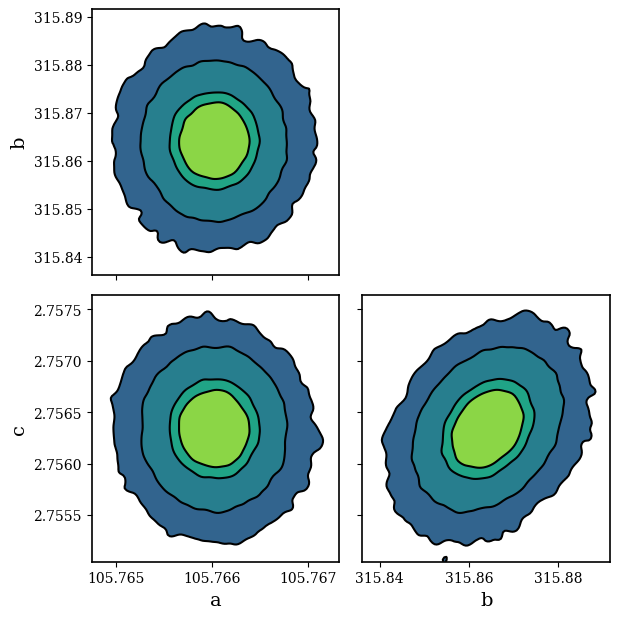

In [24]:
# Fit Kechin model with PhaseBoundaryModel
model = PhaseBoundaryModel(
    function=Kechin,
    initial_params=[100.0, 300.0, 3.0],
    x=data["P_tot (GPa)"],
    y=data["T (K)"],
    x_sig=data["P_tot_error (GPa)"],
    y_sig=data["T error"],
    states=data["state"],
    state_1="liquid",
    state_2="solid",
)
beta_k, _, dof_k, sigma_k, _, cov_k = model.fit()

# Parameter table with formatted uncertainties
param_names_k = ["a", "b", "c"]
ufloats = [ufloat(val, err) for val, err in zip(beta_k, sigma_k)]

formatted_values, formatted_errors = [], []
for u in ufloats:
    s = f"{u:.1uP}"  # “value ± error” with 1 sig fig in uncertainty
    value_str, error_str = s.split("±")
    formatted_values.append(value_str.strip())
    formatted_errors.append(error_str.strip())

df_k = pd.DataFrame(
    {
        "Parameter": param_names_k,
        "Estimate": formatted_values,
        "Standard Error": formatted_errors,
    }
)

# Posterior sampling from covariance
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="covariance is not symmetric positive-semidefinite",
        category=RuntimeWarning,
    )
    samples = np.random.multivariate_normal(mean=beta_k, cov=cov_k, size=100_000)

idata = az.from_dict(
    posterior={"a": samples[:, 0], "b": samples[:, 1], "c": samples[:, 2]}
)

# Truncate Viridis for improved contrast in KDE contours
viridis_trunc = mcolors.LinearSegmentedColormap.from_list(
    "viridis_trunc", plt.cm.viridis(np.linspace(0.3, 1.0, 256))
)

show(df_k, scrollX=False, style="margin: 0 auto; text-align: center;")
figsize = consistent_figsize(2, 2, panel_w=3, panel_h=3, wspace=0.1, hspace=0.1)
ax = az.plot_pair(
    idata,
    var_names=["a", "b", "c"],
    kind="kde",
    marginals=False,
    figsize=figsize,
    textsize=12,
    kde_kwargs={
        "hdi_probs": [0.5, 0.6827, 0.9545, 0.9973],
        "contourf_kwargs": {"cmap": viridis_trunc},
        "contour_kwargs": {"colors": "k"},
    },
)
plt.subplots_adjust(wspace=0.1, hspace=0.1)
for a_ax in np.array(ax).ravel():
    a_ax.tick_params(axis="both", labelsize=10)
    a_ax.xaxis.label.set_size(14)
    a_ax.yaxis.label.set_size(14)
plt.tight_layout()
plt.show()
plt.close()  # prevent duplicate auto-rendering

### Table S6 and Figure S2: Fitting the data to the [Simon-Glatzel equation](https://doi.org/10.1002/zaac.19291780123) using the `PhaseBoundaryModel` 

Results of fitting the Simon-Glatzel equation<sup><a href="#ref7">7</a></sup> (Eq. 1) to our phase state assignnments, made by visual analysis of x-ray diffraction patterns, using the same methodology used for the Kechin equation (table S5 and figure S1).

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


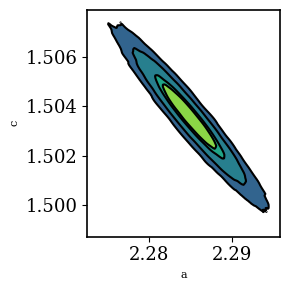

In [25]:
# Fit Simon–Glatzel model with PhaseBoundaryModel

model = PhaseBoundaryModel(
    function=Simon_Glatzel,
    initial_params=[2.0, 3.0],
    x=data["P_tot (GPa)"],
    y=data["T (K)"],
    x_sig=data["P_tot_error (GPa)"],
    y_sig=data["T error"],
    states=data["state"],
    state_1="liquid",
    state_2="solid",
)

beta_sg, _, dof_sg, sigma_sg, _, cov_sg = model.fit()

# Parameter table with formatted uncertainties
param_names_sg = ["a", "c"]
ufloats = [ufloat(val, err) for val, err in zip(beta_sg, sigma_sg)]

formatted_values, formatted_errors = [], []
for u in ufloats:
    s = f"{u:.1uP}"  # “value ± error” with 1 significant figure in the uncertainty
    value_str, error_str = s.split("±")
    formatted_values.append(value_str.strip())
    formatted_errors.append(error_str.strip())

df_sg = pd.DataFrame(
    {
        "Parameter": param_names_sg,
        "Estimate": formatted_values,
        "Standard Error": formatted_errors,
    }
)

# Posterior sampling from covariance
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="covariance is not symmetric positive-semidefinite",
        category=RuntimeWarning,
    )
    samples = np.random.multivariate_normal(mean=beta_sg, cov=cov_sg, size=100_000)

idata = az.from_dict(posterior={"a": samples[:, 0], "c": samples[:, 1]})

show(df_sg, scrollX=False, style="margin: 0 auto; text-align: center;")
figsize = consistent_figsize(1, 1, panel_w=3, panel_h=3, wspace=0, hspace=0)
ax = az.plot_pair(
    idata,
    var_names=["a", "c"],
    kind="kde",
    marginals=False,
    figsize=figsize,
    kde_kwargs={
        "hdi_probs": [0.5, 0.6827, 0.9545, 0.9973],
        "contourf_kwargs": {"cmap": viridis_trunc},
        "contour_kwargs": {"colors": "k"},
    },
)
plt.tight_layout()
plt.show()
plt.close()  # prevent duplicate auto-rendering

## Figure S3: Pressure-Temperature phase diagram for Hg

Melting points of mercury (Hg) from the literature<sup><a href="#ref1">1</a>–<a href="#ref6">6</a></sup> are shown as grey circles; corresponding grey lines and shaded fields represent fits to those data and their 95% prediction bands, assuming homoskedastic 1% uncertainties in both pressure and temperature. X-ray diffraction measurements of Hg from this study are shown as black-outlined symbols: filled squares denote solid-state data, and open circles denote liquid-state data (small symbols correspond to 60-s acquisitions; large symbols to 1200-s acquisitions for liquid structure determination). Experimental uncertainties are smaller than the symbol size in most cases. The thin yellow line and shaded field correspond to the Simon–Glatzel fit<sup><a href="#ref7">7</a></sup> and its 95% prediction band, while the thick blue line and shaded field correspond to the Kechin fit<sup><a href="#ref11">11</a></sup> and its 95% prediction band9. Residuals relative to the Kechin model are shown in the lower panel.

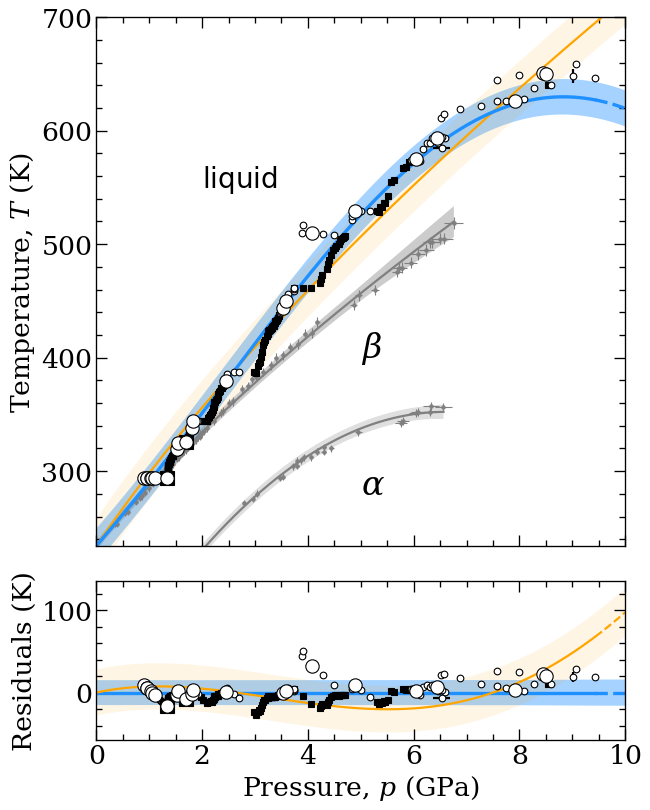

In [26]:
# Hg phase diagram

# ------------------------------------------------------------
# Figure setup & global style
# ------------------------------------------------------------
fig = plt.figure(figsize=(11, 11), dpi=80)
gs = gridspec.GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

# Axes
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax1.set_box_aspect(1)
plt.draw()  # update layout so positions are available
ax2.set_position(ax1.get_position())  # make them identical width
ax2.set_position([
    ax1.get_position().x0,
    ax1.get_position().y0 - 0.22,  # shift down manually
    ax1.get_position().width,
    0.18  # height for residual panel
])

# ------------------------------------------------------------
# Main panel: limits, labels, ticks
# ------------------------------------------------------------
ax1.set_xlim(0, 10)
ax1.set_ylim(234, 700)
ax1.set_ylabel(r"Temperature, $T$ (K)", fontsize=24)
ax1.tick_params(which="major", length=10, width=1.2,
                direction="in", top=True, right=True)
ax1.tick_params(which="minor", length=5, width=1.2,
                direction="in", top=True, right=True)
ax1.tick_params(labelbottom=False)
ax1.minorticks_on()

# ------------------------------------------------------------
# Residual panel: labels, ticks (shares x with ax1)
# ------------------------------------------------------------
ax2.set_xlabel(r"Pressure, $p$ (GPa)", fontsize=24)
ax2.set_ylabel("Residuals (K)", fontsize=24)
ax2.tick_params(which="major", length=10, width=1.2,
                direction="in", top=True, right=True)
ax2.tick_params(which="minor", length=5, width=1.2,
                direction="in", top=True, right=True)
ax2.minorticks_on()

# Convenience arrays for prediction-band smoothing
XDATA = data["P_tot (GPa)"].to_numpy()
YDATA = data["T (K)"].to_numpy()
YSIG = data["T error"].to_numpy()

# Dense x-grid for drawing fits (solid within data span; dashed outside)
xpred = np.linspace(0.0, 10.0, 800)
mask_fit_range = xpred <= XDATA.max()

# ------------------------------------------------------------
# Literature fits (prediction bands)
# ------------------------------------------------------------
# ----- α/liquid: Simon–Glatzel (literature) -----
P_fit_al = np.linspace(0, P_al.max(), 300)
T_fit_al = Simon_Glatzel(P_fit_al, *beta_al)
x_sig_al_pred = pressure_sigma(P_fit_al)           
y_var_al_pred = np.full_like(P_fit_al, 2.0**2)     

pi_al = cbands(
    func=Simon_Glatzel, beta=beta_al, x=P_fit_al,
    beta_cov=cov_al, dof=len(T_al) - len(beta_al),
    x_sig=x_sig_al_pred,
    y_var=y_var_al_pred,            
    interval="prediction",
    x_1d_mode="points",
)

ax1.fill_between(P_fit_al, T_fit_al - pi_al, T_fit_al + pi_al,
                 color="gray", alpha=0.4, lw=0, edgecolor="none", zorder=-3)
ax1.plot(P_fit_al, T_fit_al, color="gray", lw=2,
         label="Simon–Glatzel (literature)", zorder=-2)
ax1.errorbar(P_al, T_al,
             xerr=pressure_sigma(P_al), yerr=0.01*T_al,
             color="gray", fmt="o", ms=3, zorder=0, capsize=0, elinewidth=1)

# ----- β/α: polynomial (literature) -----
P_fit_ba = np.linspace(P_ba.min(), P_ba.max(), 300)
T_fit_ba = poly3(P_fit_ba, *beta_ba)
x_sig_ba_pred = pressure_sigma(P_fit_ba)
y_var_ba_pred = np.full_like(P_fit_ba, 2.0**2)    

pi_ba = cbands(
    func=poly3, beta=beta_ba, x=P_fit_ba,
    beta_cov=cov_ba, dof=len(P_ba) - len(beta_ba),
    x_sig=x_sig_ba_pred,
    y_var=y_var_ba_pred,            
    interval="prediction",
    x_1d_mode="points",
)

ax1.fill_between(P_fit_ba, T_fit_ba - pi_ba, T_fit_ba + pi_ba,
                 color="gray", alpha=0.25, lw=0, edgecolor="none", zorder=-3)
ax1.plot(P_fit_ba, T_fit_ba, color="gray", lw=2,
         label="Poly3 (literature)", zorder=-2)
ax1.errorbar(P_ba, T_ba,
             xerr=pressure_sigma(P_ba), yerr=0.01*T_ba,
             color="gray", fmt="o", ms=3, zorder=0, capsize=0, elinewidth=1)
# ------------------------------------------------------------
# This work: SG & Kechin fits + prediction bands to 10 GPa
# ------------------------------------------------------------
# Simon–Glatzel (this work)
yhat_sg_pred = Simon_Glatzel(xpred, *beta_sg)
pi_sg_pred = cbands(
    func=Simon_Glatzel, beta=beta_sg, x=xpred,
    dof=dof_sg, beta_cov=cov_sg, interval="prediction",
    data_x=XDATA, data_y=YDATA, y_sig_data=YSIG, kernel_frac=0.08
)

ax1.fill_between(
    xpred, yhat_sg_pred - pi_sg_pred, yhat_sg_pred + pi_sg_pred,
    color="orange", alpha=0.10, lw=0, edgecolor="none", zorder=-1
)
ax1.plot(xpred[mask_fit_range], yhat_sg_pred[mask_fit_range],
         "-", color="orange", lw=2, label="SG (this work)")
ax1.plot(xpred[~mask_fit_range], yhat_sg_pred[~mask_fit_range],
         "--", color="orange", lw=2)

# Kechin (this work)
yhat_k_pred = Kechin(xpred, *beta_k)
pi_k_pred = cbands(
    func=Kechin, beta=beta_k, x=xpred,
    dof=dof_k, beta_cov=cov_k, interval="prediction",
    data_x=XDATA, data_y=YDATA, y_sig_data=YSIG, kernel_frac=0.08
)

ax1.fill_between(
    xpred, yhat_k_pred - pi_k_pred, yhat_k_pred + pi_k_pred,
    color="dodgerblue", alpha=0.40, lw=0, edgecolor="none", zorder=-2
)
ax1.plot(xpred[mask_fit_range], yhat_k_pred[mask_fit_range],
         "-", color="dodgerblue", lw=3, label="Kechin (this work)")
ax1.plot(xpred[~mask_fit_range], yhat_k_pred[~mask_fit_range],
         "--", color="dodgerblue", lw=3)

# ------------------------------------------------------------
# Phase-field annotations (main panel)
# ------------------------------------------------------------
ax1.annotate(r"$\alpha$", (5, 280), fontsize=30)
ax1.annotate(r"$\beta$", (5, 400), fontsize=30)
ax1.annotate(r"$\mathrm{liquid}$", (2, 550), fontsize=25)

# ------------------------------------------------------------
# Your experimental points (this work)
# ------------------------------------------------------------
plot_points(ax1, short_solid, marker="s", ms=6, face="black", z=2)
plot_points(ax1, short_liquid, marker="o", ms=6, face="white", z=2)
plot_points(ax1, long_solid, marker="s", ms=12, face="black", z=3)
plot_points(ax1, long_liquid, marker="o", ms=12, face="white", z=3)

# ------------------------------------------------------------
# Residual panel (baseline = Kechin; SG−K overlay)
# ------------------------------------------------------------
zeros_fit = np.zeros_like(xpred[mask_fit_range])
zeros_ex = np.zeros_like(xpred[~mask_fit_range])
ax2.plot(xpred[mask_fit_range], zeros_fit, "-",
         color="dodgerblue", lw=3, label="Kechin baseline")
ax2.plot(xpred[~mask_fit_range], zeros_ex, "--",
         color="dodgerblue", lw=3, label="_nolegend_")

# Blue band around 0: ±π_K(x)
ax2.fill_between(
    xpred, -pi_k_pred, +pi_k_pred,
    color="dodgerblue", alpha=0.40, lw=0, edgecolor="none"
)

# SG − K model difference and band
res_model = yhat_sg_pred - yhat_k_pred
pi_diff = np.sqrt(pi_sg_pred ** 2 + pi_k_pred ** 2)

ax2.plot(xpred[mask_fit_range], res_model[mask_fit_range],
         "-", color="orange", lw=2, label="SG − K")
ax2.plot(xpred[~mask_fit_range], res_model[~mask_fit_range],
         "--", color="orange", lw=2, label="_nolegend_")
ax2.fill_between(
    xpred, res_model - pi_diff, res_model + pi_diff,
    color="orange", alpha=0.10, lw=0, edgecolor="none"
)

# Residual points
ax2.errorbar(
    short_solid["P_tot (GPa)"],
    residuals_vs(Kechin, beta_k, short_solid),
    xerr=short_solid["P_tot_error (GPa)"],
    yerr=short_solid["T error"],
    fmt="s", color="black", markeredgecolor="black", markersize=6,
    ecolor="black", capsize=0, elinewidth=2, zorder=2
)
ax2.errorbar(
    short_liquid["P_tot (GPa)"],
    residuals_vs(Kechin, beta_k, short_liquid),
    xerr=short_liquid["P_tot_error (GPa)"],
    yerr=short_liquid["T error"],
    fmt="o", color="white", markeredgecolor="black", markersize=6,
    ecolor="black", capsize=0, elinewidth=2, zorder=2
)
ax2.errorbar(
    long_solid["P_tot (GPa)"],
    residuals_vs(Kechin, beta_k, long_solid),
    xerr=long_solid["P_tot_error (GPa)"], yerr=long_solid["T error"],
    fmt="s", color="black", markeredgecolor="black", markersize=12,
    ecolor="black", capsize=0, elinewidth=2, zorder=3
)
ax2.errorbar(
    long_liquid["P_tot (GPa)"],
    residuals_vs(Kechin, beta_k, long_liquid),
    xerr=long_liquid["P_tot_error (GPa)"], yerr=long_liquid["T error"],
    fmt="o", color="white", markeredgecolor="black", markersize=12,
    ecolor="black", capsize=0, elinewidth=2, zorder=3
)

# ------------------------------------------------------------
# Save and render once. Earlier versions wrapped the figure in an
# Output()/VBox so it would centre, but with the inline backend the
# PNG message could land *after* the cell finished, leaving an empty
# centred VBox on "Run All". An explicit display(fig) is synchronous.
# ------------------------------------------------------------
fig.savefig("Hg_PT.png", bbox_inches="tight", pad_inches=0.02)
display(fig)
plt.close(fig)  # prevent implicit second display

## Bibliography

In [27]:
citations = load_bib_as_dict("references.bib")

# Reference list with anchors
refs = "\n".join([
    f'<a id="ref1"></a>**[1]** {citations["Klement1963"]}  ',
    f'<a id="ref2"></a>**[2]** {citations["Bridgman1911"]}  ',
    f'<a id="ref3"></a>**[3]** {citations["Bridgman1935"]}  ',
    f'<a id="ref4"></a>**[4]** {citations["Zhokhovskii1955"]}  ',
    f'<a id="ref5"></a>**[5]** {citations["Zhokhovskii1957"]}  ',
    f'<a id="ref6"></a>**[6]** {citations["Swenson1958"]}  ',
    f'<a id="ref7"></a>**[7]** {citations["Simon1929"]}  ',
    f'<a id="ref8"></a>**[8]** {citations["Zwolak2007"]}  ',
    f'<a id="ref9"></a>**[9]** {citations["Dorogokupets2007"]}  ',
    f'<a id="ref10"></a>**[10]** {citations["Cottaar2014"]}  ',
    f'<a id="ref11"></a>**[11]** {citations["Drewitt2020"]}  ',
    f'<a id="ref12"></a>**[12]** {citations["Kechin2001"]}  ',

])

display(Markdown("\n\n" + refs))



<a id="ref1"></a>**[1]** Klement, W. et al. (1963). Transformations in Mercury at High Pressures. Phys. Rev., 131, 1--6, https://link.aps.org/doi/10.1103/PhysRev.131.1  
<a id="ref2"></a>**[2]** Bridgman, P. W. (1911). Mercury, Liquid and Solid, under Pressure. Proceedings of the American Academy of Arts and Sciences, 47, 347--438, http://www.jstor.org/stable/20022750  
<a id="ref3"></a>**[3]** Bridgman, P. W. (1935). Polymorphism, Principally of the Elements, up to 50,000 kg/${\mathrm{cm}}^{2}$. Phys. Rev., 48, 893--906, https://link.aps.org/doi/10.1103/PhysRev.48.893  
<a id="ref4"></a>**[4]** Zhokhovskii, M. K. (1955). Unknown title. Izmeritel'naya Tekhnika  
<a id="ref5"></a>**[5]** Zhokhovskii, M. K. & Razumikhin, V. N. (1957). Unknown. Izmeritel'naya Tekhnika, 43  
<a id="ref6"></a>**[6]** Swenson, C. A. (1958). Phase Transition in Solid Mercury. Phys. Rev., 111, 82--91, https://link.aps.org/doi/10.1103/PhysRev.111.82  
<a id="ref7"></a>**[7]** Simon, F & Glatzel, G (1929). Bemerkungen zur Schmelzdruckkurve. Zeitschrift f�r anorganische und allgemeine Chemie, 178, 309 -- 316  
<a id="ref8"></a>**[8]** Zwolak, Jason W. et al. (2007). {Algorithm 869: ODRPACK95: A weighted orthogonal distance regression code with bound constraints}. ACM Transactions on Mathematical Software (TOMS), 33, 27, https://dl.acm.org/doi/10.1145/1268776.1268782  
<a id="ref9"></a>**[9]** Dorogokupets, P. I. & Dewaele, A. (2007). Equations of state of MgO, Au, Pt, NaCl-B1, and NaCl-B2: Internally consistent high-temperature pressure scales. High Pressure Research, 27, 431--446, https://www.tandfonline.com/doi/abs/10.1080/08957950701659700  
<a id="ref10"></a>**[10]** Cottaar, Sanne et al. (2014). {BurnMan: A lower mantle mineral physics toolkit}. Geochemistry, Geophysics, Geosystems, 15, 1164--1179, https://agupubs.onlinelibrary.wiley.com/doi/10.1002/2013GC005122  
<a id="ref11"></a>**[11]** Drewitt, J. W. E. et al. (2020). Structural Ordering in Liquid Gallium under Extreme Conditions. Physical Review Letters, 124, 145501, https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.124.145501  
<a id="ref12"></a>**[12]** Kechin, V. (2001). Melting curve equations at high pressure. Physical Review B, 65, 052102  